# Lineare Regression: Einkommen vorhersagen (`ConvertedTotalComp`)



In [3]:
import pandas as pd
import numpy as np


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [4]:

df = pd.read_csv("../One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

count     19651.000000
mean      72290.175189
std       46359.016652
min           0.000000
25%       36043.905168
50%       70068.000000
75%      105102.000000
max      175170.000000
Name: ConvertedCompTotal, dtype: float64


MaxAge                                                            float64
AgeNum                                                            float64
WorkExp                                                           float64
YearsCode                                                         float64
RemoteCategoryNum                                                 float64
                                                                   ...   
AIAgents_no, i use ai exclusively in copilot/autocomplete mode      int64
AIAgents_yes, i use ai agents at work daily                         int64
AIAgents_yes, i use ai agents at work monthly or infrequently       int64
AIAgents_yes, i use ai agents at work weekly                        int64
AIAgents_nan                                                        int64
Length: 338, dtype: object

#### Ausreißer entfernen
- Berechnet das 98. Perzentil der Gehälter (`ConvertedCompTotal`)
- Behält nur Zeilen, deren Gehalt unter diesem Schwellenwert liegt

#### Datentypen anpassen
- Findet alle Spalten mit booleschem Datentyp
- Konvertiert diese Spalten in Integer (0/1)


In [5]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()
X = X.drop(columns=["ConvertedCompYearly"])


# Konsistentes Dropna (X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (13839, 321) y: (13839,)


count     13839.000000
mean      76840.187215
std       44254.097054
min           0.000000
25%       44772.045540
50%       74362.963600
75%      107439.892051
max      175170.000000
Name: ConvertedCompTotal, dtype: float64

#### 1. Zielvariable und Features definieren
- **Zielvariable (y)**: `ConvertedCompTotal` (jährliches Gesamtgehalt)
- **Features (X)**: Alle numerischen Spalten außer:
  - Der Zielvariable selbst
  - `ConvertedCompYearly` (wurde explizit ausgeschlossen)

#### 2. Datenbereinigung
- **Fehlende Werte**: 
  - Beide Datensätze (X und y) werden auf vollständige Zeilen reduziert
  - Nur Zeilen ohne fehlende Werte in X und y werden beibehalten

#### 3. Ausgabe
- **Dimensionen** der bereinigten Datensätze (X und y)
- **Statistische Zusammenfassung** der Zielvariablen:
  - Mittelwert, Standardabweichung
  - Min/Max-Werte
  - Quartile

#### Zweck
- Vorbereitung der Daten für das maschinelle Lernen
- Sicherstellung der Datenqualität durch Entfernen fehlender Werte
- Trennung in Features (X) und Zielvariable (y)

In [6]:
y_model = y.astype(float)
y_model.head()

0     61659.84
1    105102.00
2     36435.36
6     72000.00
7     70000.00
Name: ConvertedCompTotal, dtype: float64

Die Zielvariable `y` wird in den Datentyp `float` (Gleitkommazahl) umgewandelt

In [7]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (11071, 321) Test: (2768, 321)


#### Train/Test Split
- **Aufteilung**: 80% Training, 20% Test
- **Zweck**: Modelltraining und -bewertung
- **Reproduzierbarkeit**: `random_state=42`
- **Ausgabe**: Größe der Datensätze (Beispiele × Features)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["MaxAge", "AgeNum", "WorkExp", "YearsCode", "RemoteCategoryNum"]
dummy_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("dum", "passthrough", dummy_cols),
    ],
    remainder="drop"
)


#### Datenvorverarbeitung mit ColumnTransformer

##### 1. Spaltendefinition
- **Numerische Spalten**: `MaxAge`, `AgeNum`, `WorkExp`, `YearsCode`, `RemoteCategoryNum`
- **Dummy-Spalten**: Alle anderen Spalten

##### 2. Transformationen
- **Numerische Spalten**: Standardisierung (Mittelwert=0, Standardabweichung=1)
- **Dummy-Spalten**: Keine Änderung (`passthrough`)

##### 3. ColumnTransformer
- Ermöglicht verschiedene Transformationen für verschiedene Spaltentypen
- Nicht spezifizierte Spalten werden entfernt (`remainder="drop"`)

In [9]:

scaler = StandardScaler()
X_train_sc = preprocess.fit_transform(X_train)
X_test_sc  = preprocess.transform(X_test)



#### Skalierung der Daten

##### Was passiert?
- **Trainingstransformation**:
  - Berechnet Mittelwert/Standardabweichung
  - Transformiert Trainingsdaten
- **Testtransformation**:
  - Wendet gleiche Skalierung wie beim Training an
  - Verhindert Data Leakage

##### Wichtig
- `fit_transform` für Trainingsdaten
- `transform` für Testdaten
- Behält die ursprüngliche Datenstruktur bei

In [10]:
clf = LinearRegression()
clf.fit(X_train_sc, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Lineare Regression Training

##### Was passiert?
- Initialisiert ein lineares Regressionsmodell
- Trainiert das Modell mit den skalierten Trainingsdaten

##### Parameter
- `X_train_sc`: Skalierte Features (unabhängige Variablen)
- `y_train`: Zielvariable (abhängige Variable)

##### Ergebnis
Das Modell lernt die Beziehung zwischen Features und Zielvariable, um Vorhersagen zu treffen.

In [11]:
predicted = clf.predict(X_test_sc)
expected = y_test

print ("RMSE:")
rmse = np.sqrt(mean_squared_error(expected, predicted))
print (rmse)
print("R^2:")
r2 = r2_score(expected, predicted)
print (r2)
print("MAE:")
mae = mean_absolute_error(expected, predicted)
print (mae)

RMSE:
28586.14574162176
R^2:
0.5975409646591797
MAE:
21232.614196037703


#### Modellbewertung

##### Metriken
- **RMSE (Root Mean Squared Error)**: 28.586,15
  - Durchschnittlicher Fehler in der Einheit der Zielvariable
  - Stärkere Gewichtung größerer Fehler

- **R² (Bestimmtheitsmaß)**: 0,598
  - Erklärte Varianz: ~60%
  - Skaliert von 0 (schlecht) bis 1 (perfekt)

- **MAE (Mean Absolute Error)**: 21.232,61
  - Durchschnittlicher absoluter Fehler
  - Leichter zu interpretieren als RMSE

##### Interpretation
- Das Modell erklärt etwa 60% der Varianz in den Daten
- Der durchschnittliche Vorhersagefehler beträgt etwa 21.233 Dollar
- Generell ist das Modell akzeptabel
- Bei geringeren Gehältern ist eine Abweichung von 21.000 Dollar noch zu hoch für eine präzise Vorhersage

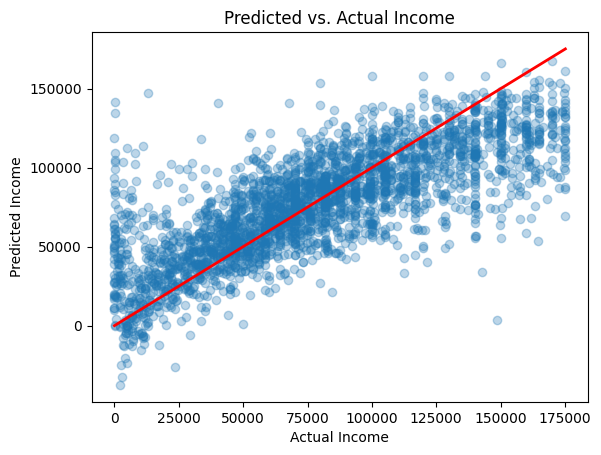

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(expected, predicted, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



#### Streudiagramm: Tatsächliche vs. Vorhergesagte Werte

##### Was wird gezeigt?
- **Punktewolke**: Jeder Punkt = Datenpunkt
  - **x-Achse**: Tatsächliche Einkommen
  - **y-Achse**: Vorhergesagte Einkommen
- **Rote Linie**: Perfekte Vorhersage (y = x)

##### Auswertung
- **Korrelation**: Klare diagonale Ausrichtung zeigt gute Übereinstimmung
- **Beste Vorhersagen**: Im mittleren Einkommensbereich (50k-100k)
- **Abweichungen**:
  - Leichte Überschätzung bei mittleren Einkommen
  - Zunehmende Streuung bei hohen Einkommen (>150k)
  - Einige Ausreißer bei niedrigen Einkommen
- **Modellgrenzen**: Lineares Modell geeignet, aber bei Extremwerten ungenauer



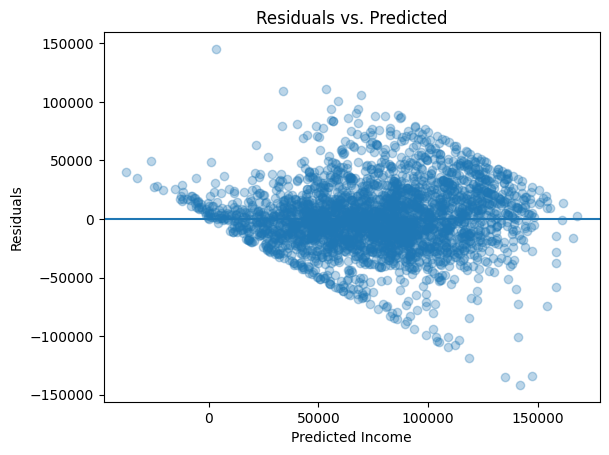

In [13]:
residuals = expected - predicted

plt.figure()
plt.scatter(predicted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


#### Residuenanalyse

##### Was wird gezeigt?
- **Residuen**: Differenz zwischen tatsächlichen und vorhergesagten Werten
- **Horizontale Linie bei 0**: Idealfall (kein Fehler)

##### Auswertung
- **Trichterform**: Deutliche Zunahme der Streuung nach rechts (Heteroskedastizität)
- **Mittlerer Bereich (50k-100k)**: Geringere Streuung um die Nulllinie
- **Höhere Einkommen**: Deutlich mehr Streuung und Ausreißer
- **Muster**: Hohe Gehälter werden eher unteschätzt und niedrige Gehälter werden eher überschätzt 


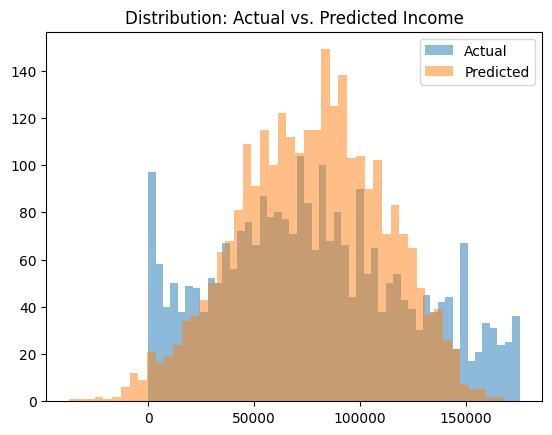

In [14]:
plt.figure()
plt.hist(expected, bins=50, alpha=0.5, label="Actual")
plt.hist(predicted, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()


#### Verteilungsvergleich

##### Was wird verglichen?
- **Blaue Balken**: Tatsächliche Einkommen
- **Orange Balken**: Vom Modell vorhergesagte Einkommen

##### Auswertung
- **Häufigkeitsverteilung**: Gute Übereinstimmung im mittleren Bereich (50k-100k)
- **Abweichungen**:
  - **Niedrige Einkommen**: Modell unterschätzt die Häufigkeit von Werten nahe 0
  - **Hohe Einkommen**: Leichte Unterschätzung der Häufigkeit sehr hoher Einkommen
- **Streuung**: Vorhergesagte Verteilung ist schmaler, was auf eine Unterschätzung der Varianz hindeutet
s
